# 🏥 Modelo de Predicción de Primas de Seguros

## 📋 Descripción del Proyecto

Como parte del **equipo de tarifación de una aseguradora**, se requiere construir un modelo predictivo que pueda pronosticar el valor de la prima de un asegurado con una precisión específica.

### 🎯 Objetivo
Desarrollar un modelo que logre un **MAPE ≤ 15%** para la predicción del valor de las primas de seguros.

## 📊 Diccionario de Datos

El conjunto de datos contiene las siguientes variables:

| Variable | Descripción |
|----------|-------------|
| **Age** | Edad del asegurado |
| **Sex** | Género del asegurado |
| **Bmi** | Índice de masa corporal del asegurado |
| **Children** | Número de hijos del asegurado |
| **Smoker** | El asegurado es o no fumador |
| **Region** | Región comercial a la que pertenece el asegurado |
| **Charges** | Valor de la prima del asegurado *(Variable objetivo)* |

### 📈 Métrica de Evaluación
- **MAPE** (Mean Absolute Percentage Error) ≤ 15%

# 4. Recolección de Datos

In [29]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv('datos_caso_3.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# 5. Entendimiento de los Datos
- Conocer nuestra variable y
- Analisis univariado y multivariado

## Variable Y (charges)

In [32]:
target = 'charges'

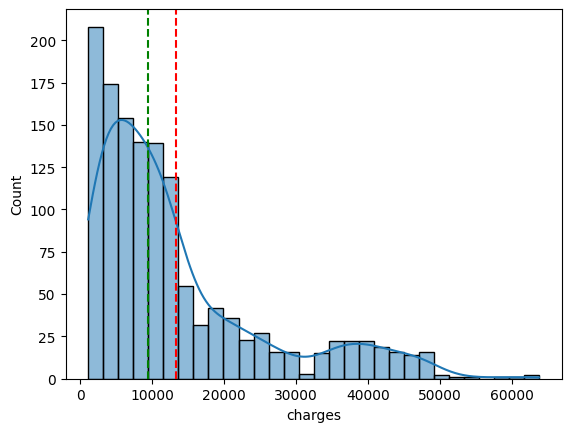

In [69]:
sb.histplot(data = data, x = target, kde = True)
plt.axvline(x = data[target].mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data[target].median(), color = 'green', linestyle = 'dashed')
plt.show()

## Exploración univariada de los datos

In [31]:
import matplotlib.pyplot as plt
import seaborn as sb

### Variables numericas

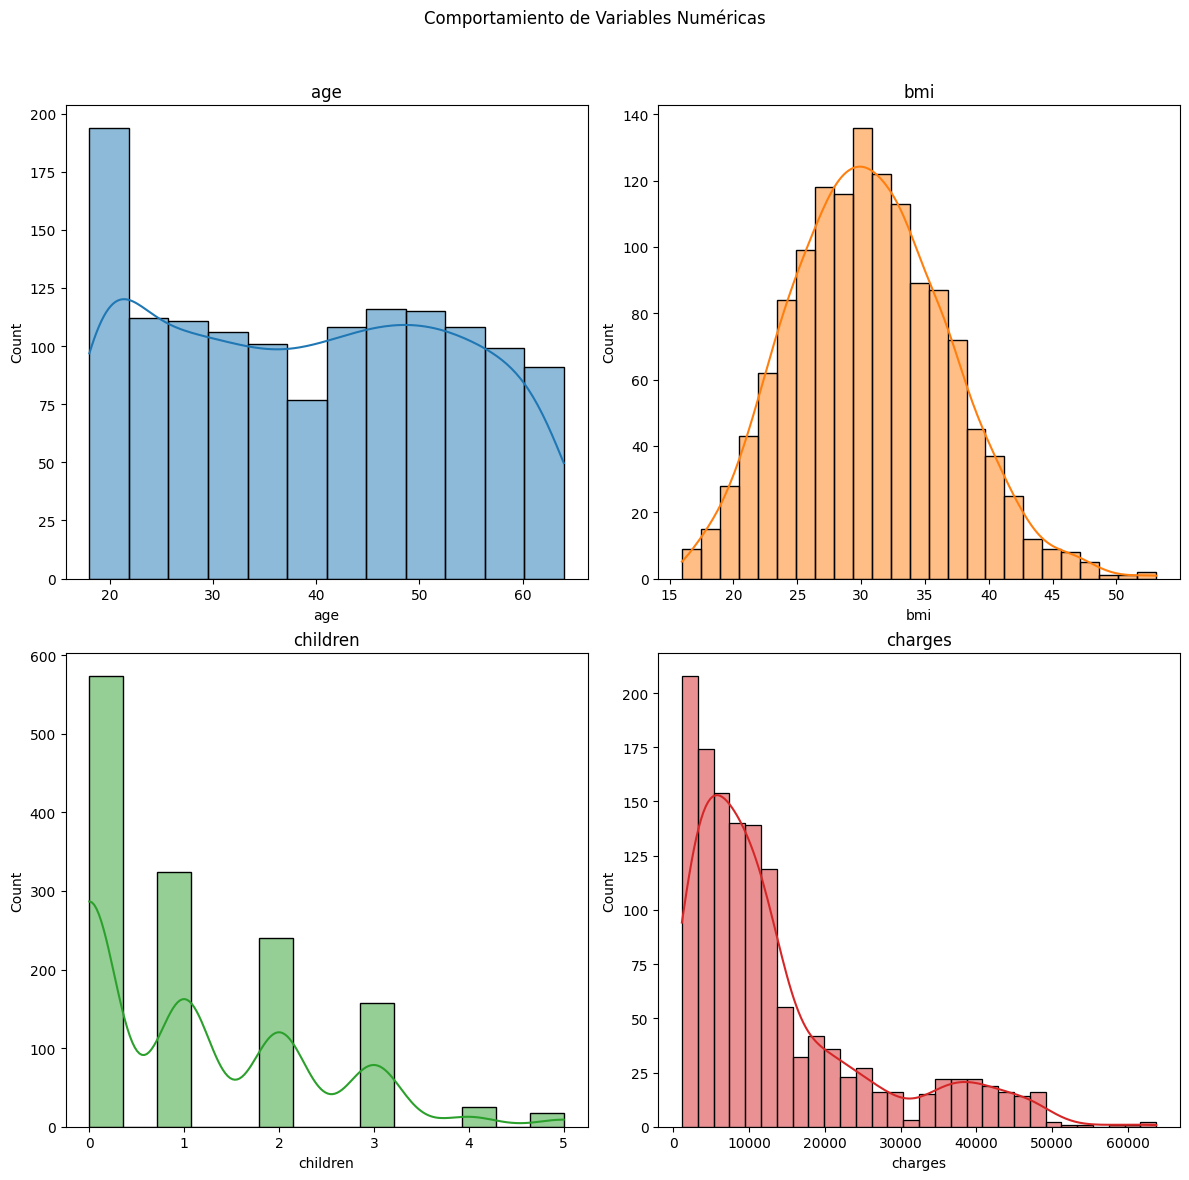

In [33]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns

for i, col in enumerate(num_col):
  sb.histplot(
    data = data,
    x = col, 
    kde = True,
    color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
    ax = ax[i]
  )
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

### Variables categoricas

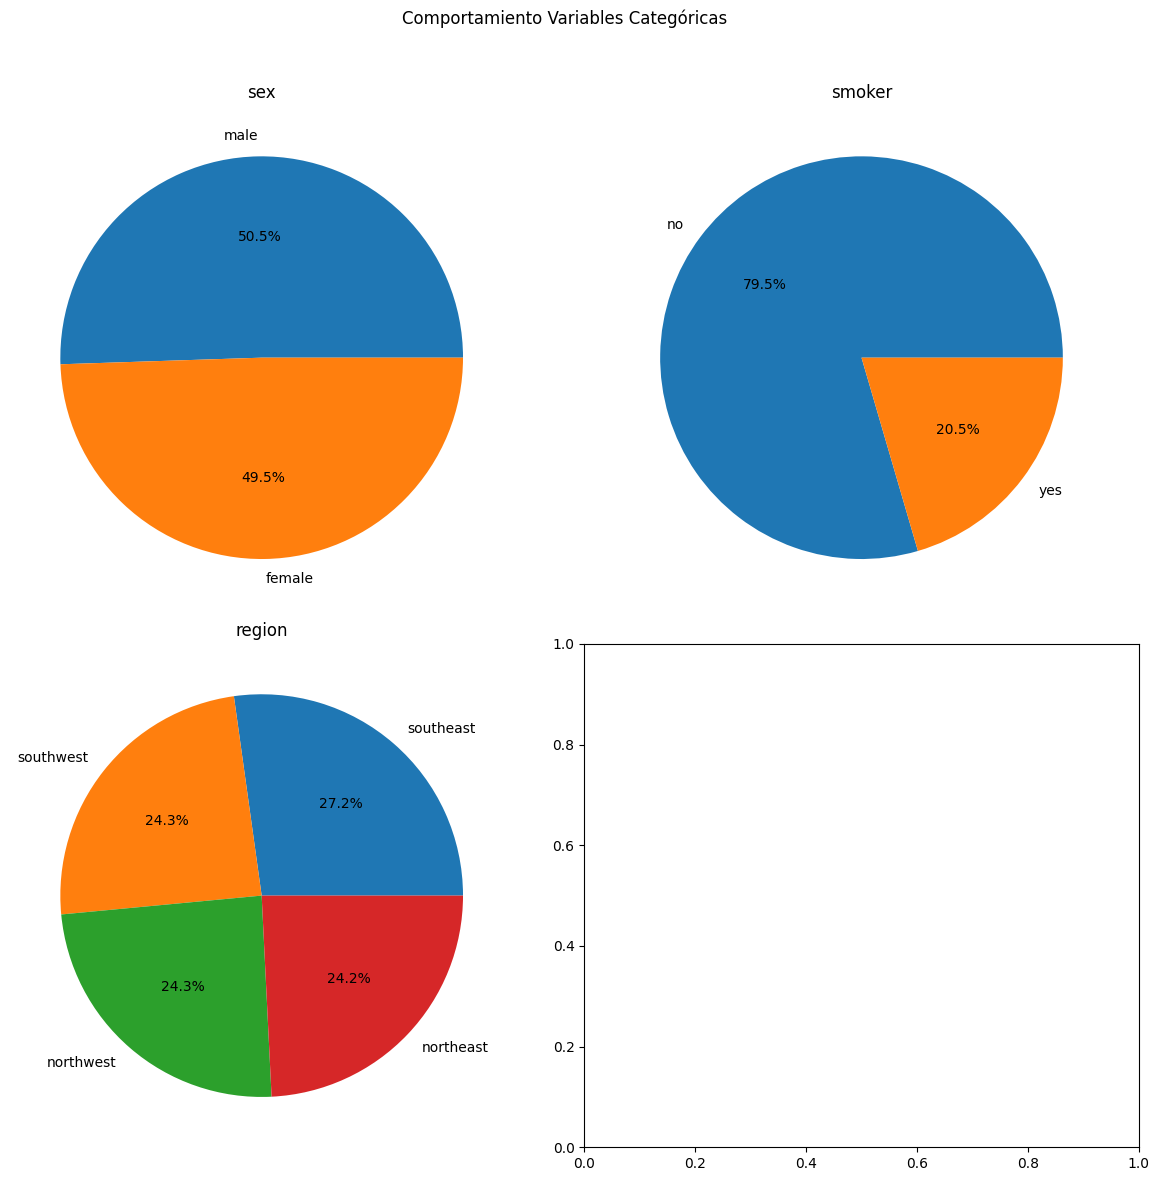

In [34]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns

for i, col in enumerate(cat_col):
  ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

## Correlacion

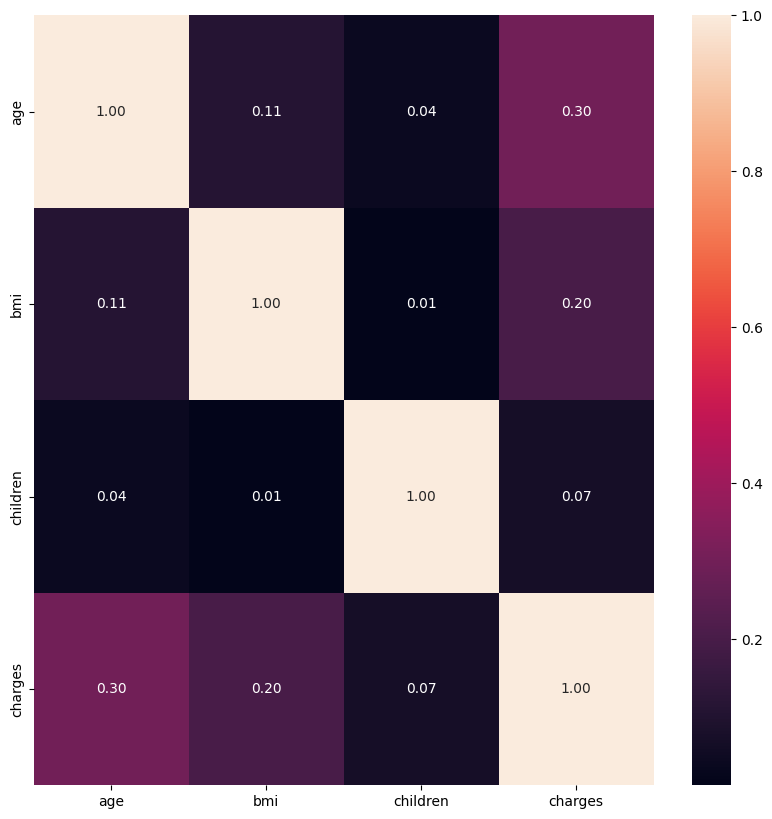

In [35]:
plt.figure(figsize=(10, 10))
sb.heatmap(data.corr(numeric_only = True), annot=True, fmt='.2f')
plt.show()

# 6. Preparación de los Datos

## Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

In [37]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = data.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder())])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
  ],
  remainder='passthrough'
)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [38]:
data_pre = preprocessor.fit_transform(data)

cod_cat = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])

data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,0.251611,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,0.009636,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,0.053115,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,0.333010,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,0.043816,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.695652,0.403820,0.6,0.151299,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,0.000000,0.429379,0.0,0.017305,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,0.000000,0.562012,0.0,0.008108,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,0.065217,0.264730,0.0,0.014144,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## Separacion variables X y Y

In [39]:
X = data_pro.drop(columns = target, axis = 1)
y = data_pro[target]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=123)
print(f'El tamaño del conjunto de prueba es: {X_test.shape} {y_test.shape}')
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}')

El tamaño del conjunto de prueba es: (937, 11) (937,)
El tamaño del conjunto de entrenamiento es: (401, 11) (401,)


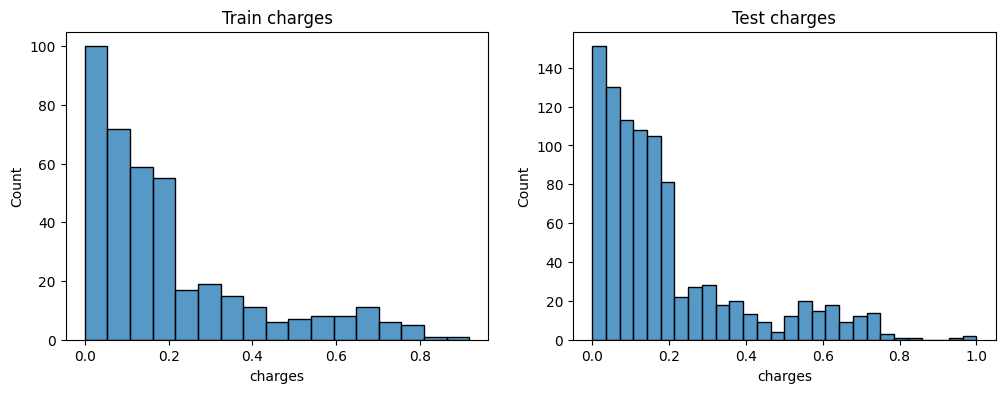

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sb.histplot(y_train, ax=ax[0])
ax[0].set_title(f'Train {target}')

sb.histplot(y_test, ax=ax[1])
ax[1].set_title(f'Test {target}')

plt.show()

# 7. Modelado

- Regresion lineal
- K vecinos mas cercanos
- Maquina de soporte vectorial
- Arboles de decision
- Random Forest
- Gradient Boosting
- Percepcion Multicapa

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Regresion lineal

In [43]:
modelo_1 = LinearRegression()
modelo_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
modelo_1.coef_

array([ 0.18152455,  0.24378779,  0.02183742,  0.00323495, -0.00323495,
       -0.18477517,  0.18477517,  0.00822192,  0.00804215, -0.01054098,
       -0.00572309])

In [45]:
modelo_1.intercept_

np.float64(0.11733012615333509)

## K Vecinos más cercanos

In [46]:
modelo_2 = KNeighborsRegressor()

param_grid = {
  'n_neighbors': [2, 5, 9, 15, 25, 40, 35],
  'p': [1, 2],
}

reg_2 = GridSearchCV(estimator=modelo_2, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_2.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_2.cv_results_['params']),
    pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,n_neighbors,p,MAPE
0,2,1,-2.272675e+09
1,2,2,-2.272675e+09
2,5,1,-5.482447e+10
3,5,2,-1.180095e+11
13,35,2,-6.303582e+11
6,15,1,-6.531083e+11
7,15,2,-6.736321e+11
10,40,1,-7.115185e+11
11,40,2,-7.153110e+11
4,9,1,-7.205909e+11


In [47]:
modelo_2_final = reg_2.best_estimator_
modelo_2_final

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Maquina de soporte Vectorial

In [48]:
modelo_3 = SVR()

param_grid = {
  'C': [0, 0.01, 1, 10, 100],
  'kernel': ['linear', 'poly', 'rbf'],
  'degree': [2, 3]
}

reg_3 = GridSearchCV(estimator=modelo_3, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_3.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_3.cv_results_['params']),
    pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,C,degree,kernel,MAPE
29,100.00,3,rbf,-2.484346e+11
26,100.00,2,rbf,-2.484346e+11
28,100.00,3,poly,-6.407678e+11
21,10.00,3,linear,-6.512853e+11
18,10.00,2,linear,-6.512853e+11
24,100.00,2,linear,-6.562992e+11
27,100.00,3,linear,-6.562992e+11
12,1.00,2,linear,-6.578051e+11
15,1.00,3,linear,-6.578051e+11
22,10.00,3,poly,-1.025671e+12


In [49]:
modelo_3_final = reg_3.best_estimator_
modelo_3_final

,kernel,'rbf'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Arbol de Regresion

In [50]:
modelo_4 = DecisionTreeRegressor(random_state=123)

param_grid = {
  'criterion': ['friedman_mse', 'poisson', 'squared_error', 'absolute_error'],
  'max_depth': [None, 5, 6, 3, 4, 10, 100],
  'max_leaf_nodes': [None, 2, 3, 4]
}

reg_4 = GridSearchCV(estimator=modelo_4, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_4.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_4.cv_results_['params']),
    pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,criterion,max_depth,max_leaf_nodes,MAPE
20,friedman_mse,10.0,NaN,-1.735497e+09
56,squared_error,NaN,NaN,-1.735497e+09
80,squared_error,100.0,NaN,-1.735497e+09
0,friedman_mse,NaN,NaN,-1.735497e+09
24,friedman_mse,100.0,NaN,-1.735497e+09
...,...,...,...,...
69,squared_error,3.0,2.0,-1.246471e+12
53,poisson,100.0,2.0,-1.246471e+12
49,poisson,10.0,2.0,-1.246471e+12
57,squared_error,NaN,2.0,-1.246471e+12


In [51]:
modelo_4_final = reg_4.best_estimator_
modelo_4_final

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Bosque Aleatorio

In [52]:
modelo_5 = RandomForestRegressor(random_state=123)

param_grid = {
  'n_estimators': [100, 200, 500],
  'criterion': ['friedman_mse', 'poisson', 'squared_error', 'absolute_error'],
  'max_depth': [None, 5, 6, 3, 4, 10, 100],
  'max_leaf_nodes': [None, 2, 3, 5]
}

reg_5 = GridSearchCV(estimator=modelo_5, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_5.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_5.cv_results_['params']),
    pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,criterion,max_depth,max_leaf_nodes,n_estimators,MAPE
156,poisson,100.0,NaN,100,-3.907394e+10
84,poisson,NaN,NaN,100,-3.907394e+10
144,poisson,10.0,NaN,100,-3.993508e+10
157,poisson,100.0,NaN,200,-4.135936e+10
85,poisson,NaN,NaN,200,-4.135936e+10
...,...,...,...,...,...
64,friedman_mse,10.0,2.0,200,-1.244059e+12
52,friedman_mse,4.0,2.0,200,-1.244059e+12
40,friedman_mse,3.0,2.0,200,-1.244059e+12
244,squared_error,100.0,2.0,200,-1.244059e+12


In [53]:
modelo_5_final = reg_5.best_estimator_
modelo_5_final

,n_estimators,100
,criterion,'poisson'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Adaptative Boosting

In [54]:
modelo_6 = AdaBoostRegressor()

param_grid = {
  'n_estimators': [100, 200, 400, 600],
  'loss': ['linear', 'square', 'exponential'],
  'learning_rate': [0.001, 0.1, 1, 10]
}

reg_6 = GridSearchCV(estimator=modelo_6, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_6.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_6.cv_results_['params']),
    pd.DataFrame(reg_6.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,learning_rate,loss,n_estimators,MAPE
4,0.001,square,100,-3.936513e+11
8,0.001,exponential,100,-4.102019e+11
10,0.001,exponential,400,-4.233961e+11
1,0.001,linear,200,-4.248613e+11
9,0.001,exponential,200,-4.305757e+11
2,0.001,linear,400,-4.330435e+11
11,0.001,exponential,600,-4.397810e+11
0,0.001,linear,100,-4.405299e+11
3,0.001,linear,600,-4.413253e+11
6,0.001,square,400,-4.517366e+11


In [55]:
modelo_6_final = reg_6.best_estimator_
modelo_6_final

,estimator,None
,n_estimators,100
,learning_rate,0.001
,loss,'square'
,random_state,None


## Gradiant Boosting

In [56]:
modelo_7 = GradientBoostingRegressor()

param_grid = {
  'n_estimators': [100, 200, 400, 500, 1000],
  'loss': ['squared_error', 'absolute_error'],
  'criterion': ['friedman_mse', 'squared_error'],
}

reg_7 = GridSearchCV(estimator=modelo_7, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_7.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_7.cv_results_['params']),
    pd.DataFrame(reg_7.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,criterion,loss,n_estimators,MAPE
8,friedman_mse,absolute_error,500,-2.724621e+10
15,squared_error,absolute_error,100,-3.537735e+10
9,friedman_mse,absolute_error,1000,-3.744035e+10
18,squared_error,absolute_error,500,-4.688549e+10
5,friedman_mse,absolute_error,100,-4.738010e+10
7,friedman_mse,absolute_error,400,-5.329240e+10
16,squared_error,absolute_error,200,-6.089723e+10
19,squared_error,absolute_error,1000,-7.690008e+10
6,friedman_mse,absolute_error,200,-9.159382e+10
17,squared_error,absolute_error,400,-1.077977e+11


In [57]:
modelo_7_final = reg_7.best_estimator_
modelo_7_final

,loss,'absolute_error'
,learning_rate,0.1
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Perceptor multicapa

In [58]:
modelo_8 = MLPRegressor(random_state=123)

param_grid = {
  'hidden_layer_sizes': [(10,), (10,10,), (10,10,10,), (20,10,)],
  'activation': ['relu', 'tanh', 'logistic'],
  'solver': ['adam', 'sgd', 'lbfgs'],
  'max_iter': [200, 300, 400],
  'learning_rate_init': [0.001, 0.01, 0.1, 1, 10]
}

reg_8 = GridSearchCV(estimator=modelo_8, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_8.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_8.cv_results_['params']),
    pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

,activation,hidden_layer_sizes,learning_rate_init,max_iter,solver,MAPE
519,logistic,"(20, 10)",0.1,400,adam,-5.292009e+09
513,logistic,"(20, 10)",0.1,200,adam,-5.292009e+09
516,logistic,"(20, 10)",0.1,300,adam,-5.292009e+09
384,logistic,"(10,)",0.1,400,adam,-9.507237e+09
378,logistic,"(10,)",0.1,200,adam,-9.507237e+09
...,...,...,...,...,...,...
265,tanh,"(10, 10)",10.0,300,sgd,-4.710403e+66
268,tanh,"(10, 10)",10.0,400,sgd,-4.710403e+66
355,tanh,"(20, 10)",10.0,300,sgd,-4.666915e+67
358,tanh,"(20, 10)",10.0,400,sgd,-4.666915e+67


In [59]:
modelo_8_final = reg_8.best_estimator_
modelo_8_final

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.1
,power_t,0.5
,max_iter,200
,shuffle,True


# 8. Validacion

- Ajuste cuadrfatico
- Raiz del error cuadratico medio
- Error medio absoluto
- Porcentaje del error medio absoluto

## Funciones de validacion

In [60]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

def predecir_y_desescalar(modelo, X_train, X_test, y_train, y_test, y_total):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    y_min, y_max = np.min(y_total), np.max(y_total)
    pred_train_des = pred_train * (y_max - y_min) + y_min
    pred_test_des = pred_test * (y_max - y_min) + y_min
    y_train_des = y_train * (y_max - y_min) + y_min
    y_test_des = y_test * (y_max - y_min) + y_min
    return pred_train_des, pred_test_des, y_train_des, y_test_des

def mostrar_metricas(y_train_des, pred_train_des, y_test_des, pred_test_des, nombre_modelo="Modelo"):
    # Entrenamiento
    r2_train = r2_score(y_train_des, pred_train_des)
    rmse_train = root_mean_squared_error(y_train_des, pred_train_des)
    mae_train = mean_absolute_error(y_train_des, pred_train_des)
    mape_train = mean_absolute_percentage_error(y_train_des, pred_train_des) * 100

    print(f"Las métricas de desempeño en entrenamiento para {nombre_modelo} son:")
    print(f"R2: {r2_train}")
    print(f"RMSE: {rmse_train}")
    print(f"MAE: {mae_train}")
    print(f"MAPE: {mape_train / 100}")

    sb.histplot(data=y_train_des, label='Datos de entrenamiento')
    sb.histplot(pred_train_des, label='Predicciones de entrenamiento')
    plt.legend()
    plt.show()

    # Test
    r2_test = r2_score(y_test_des, pred_test_des)
    rmse_test = root_mean_squared_error(y_test_des, pred_test_des)
    mae_test = mean_absolute_error(y_test_des, pred_test_des)
    mape_test = mean_absolute_percentage_error(y_test_des, pred_test_des) * 100

    print(f"Las métricas de desempeño en test para {nombre_modelo} son:")
    print(f"R2: {r2_test}")
    print(f"RMSE: {rmse_test}")
    print(f"MAE: {mae_test}")
    print(f"MAPE: {mape_test / 100}")

    sb.histplot(data=y_test_des, label='Datos de test')
    sb.histplot(pred_test_des, label='Predicciones de test')
    plt.legend()
    plt.show()

## Regresion lineal

Las métricas de desempeño en entrenamiento para Regresión Lineal son:
R2: 0.7425426724462072
RMSE: 0.10013320261693442
MAE: 0.07107799427141406
MAPE: 378147569471.1677


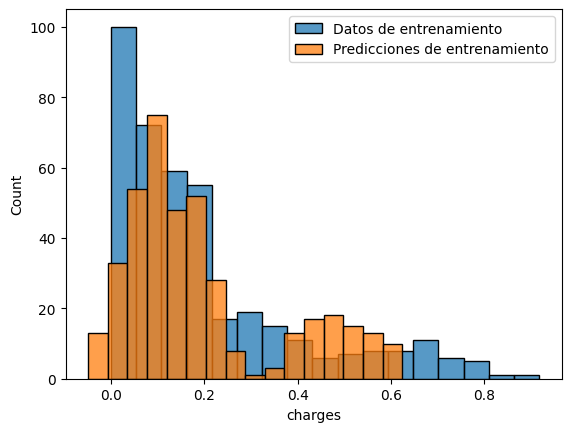

Las métricas de desempeño en test para Regresión Lineal son:
R2: 0.7511166101968897
RMSE: 0.09550051225141958
MAE: 0.0682067279837222
MAPE: 1.7777101680675798


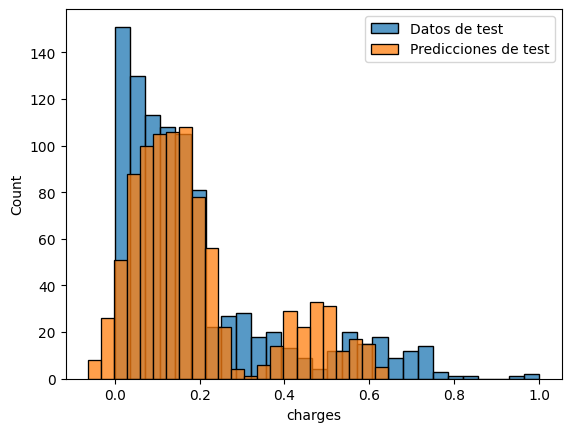

In [61]:
pred_train_1, pred_test_1, y_train_des, y_test_des = predecir_y_desescalar(modelo_1, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_1, y_test_des, pred_test_1, nombre_modelo="Regresión Lineal")

## K Vecinos mas cercanos

Las métricas de desempeño en entrenamiento para KNN son:
R2: 0.9127894548476438
RMSE: 0.05827871654451005
MAE: 0.03079087086693176
MAPE: 48682705701.86531


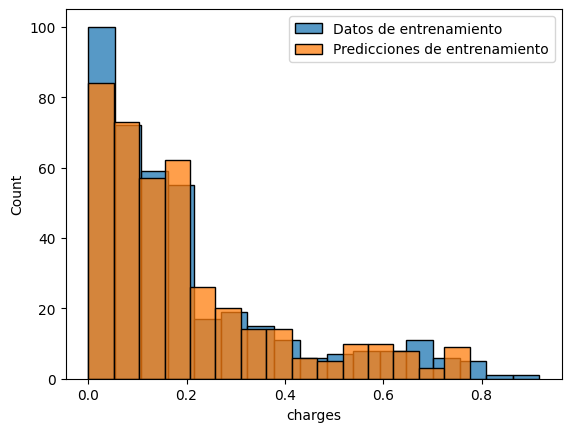

Las métricas de desempeño en test para KNN son:
R2: 0.6954846054305976
RMSE: 0.10563610290070839
MAE: 0.06154398987498314
MAPE: 0.49243890698767545


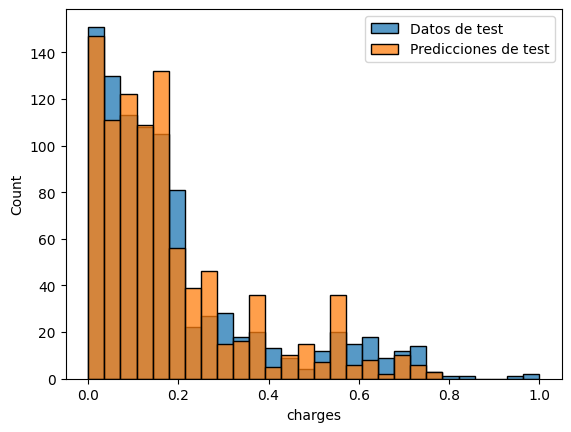

In [62]:
pred_train_2, pred_test_2, y_train_des, y_test_des = predecir_y_desescalar(modelo_2_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_2, y_test_des, pred_test_2, nombre_modelo="KNN")

## Maquina de Soporte Vectorial

Las métricas de desempeño en entrenamiento para MSV son:
R2: 0.845870445642608
RMSE: 0.07747622283345691
MAE: 0.06720575851830443
MAPE: 91353500269.22826


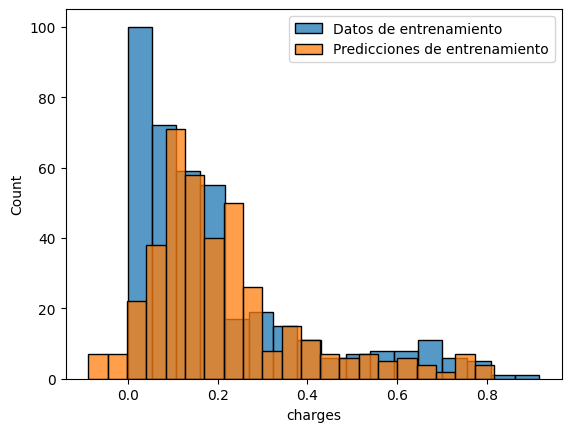

Las métricas de desempeño en test para MSV son:
R2: 0.6385762982462171
RMSE: 0.11508429439364293
MAE: 0.08799901179616973
MAPE: 2.9793091906284648


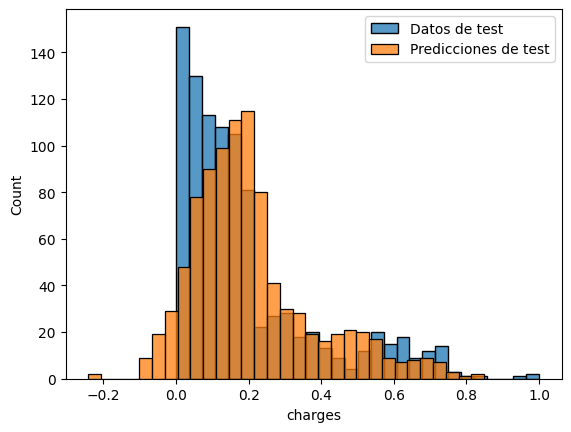

In [63]:
pred_train_3, pred_test_3, y_train_des, y_test_des = predecir_y_desescalar(modelo_3_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_3, y_test_des, pred_test_3, nombre_modelo="MSV")

## Arbol de Regresion

Las métricas de desempeño en entrenamiento para Arbol Regresion son:
R2: 0.9781890026423784
RMSE: 0.02914494504726612
MAE: 0.008206483241304859
MAPE: 0.110336550378476


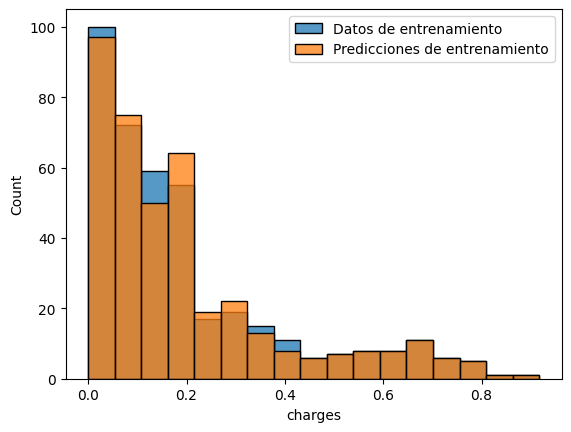

Las métricas de desempeño en test para Arbol Regresion son:
R2: 0.7447222423644788
RMSE: 0.09671954229170049
MAE: 0.04881180177675654
MAPE: 0.5681171893193357


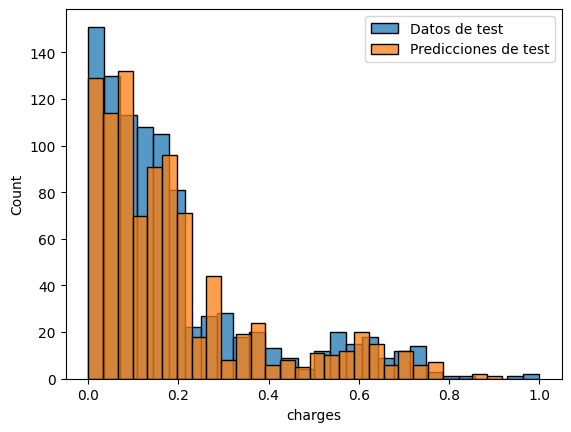

In [64]:
pred_train_4, pred_test_4, y_train_des, y_test_des = predecir_y_desescalar(modelo_4_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_4, y_test_des, pred_test_4, nombre_modelo="Arbol Regresion")

## Bosque aleatorio

Las métricas de desempeño en entrenamiento para Random Forest son:
R2: 0.9766084927898943
RMSE: 0.030182456352500855
MAE: 0.01547873549474523
MAPE: 25048259888.661865


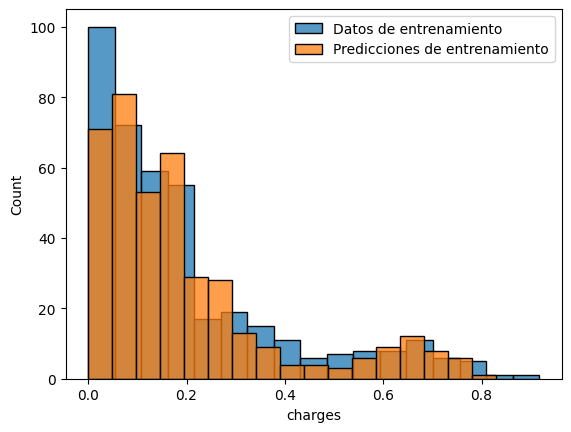

Las métricas de desempeño en test para Random Forest son:
R2: 0.8437679550511072
RMSE: 0.07566461090901594
MAE: 0.04192842023859934
MAPE: 0.4815743558551555


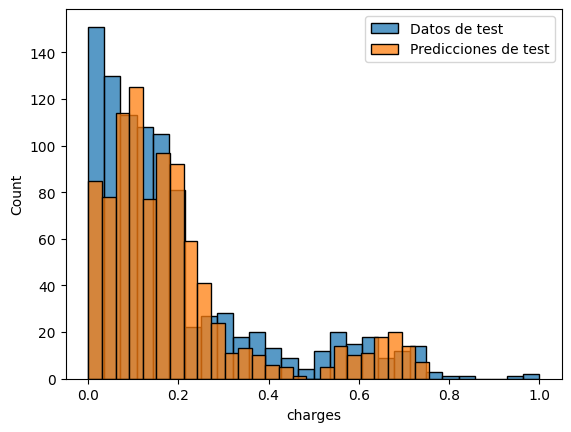

In [65]:
pred_train_5, pred_test_5, y_train_des, y_test_des = predecir_y_desescalar(modelo_5_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_5, y_test_des, pred_test_5, nombre_modelo="Random Forest")

## Adaptative Boosting

Las métricas de desempeño en entrenamiento para Adaptative Boosting son:
R2: 0.8674616981034817
RMSE: 0.07184493881215365
MAE: 0.04275979193586436
MAPE: 435175200212.5581


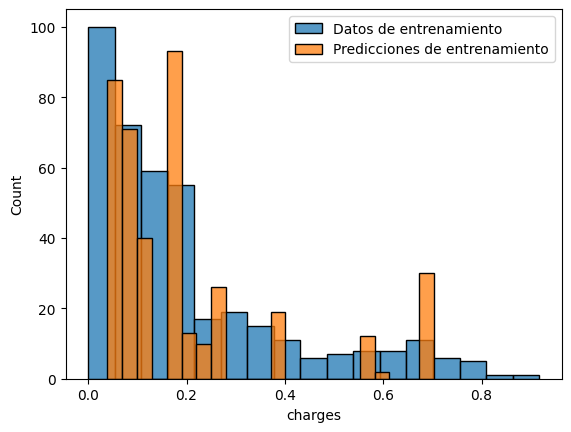

Las métricas de desempeño en test para Adaptative Boosting son:
R2: 0.8511244594432289
RMSE: 0.07386172057984898
MAE: 0.04437661848532904
MAPE: 1.3985981175998694


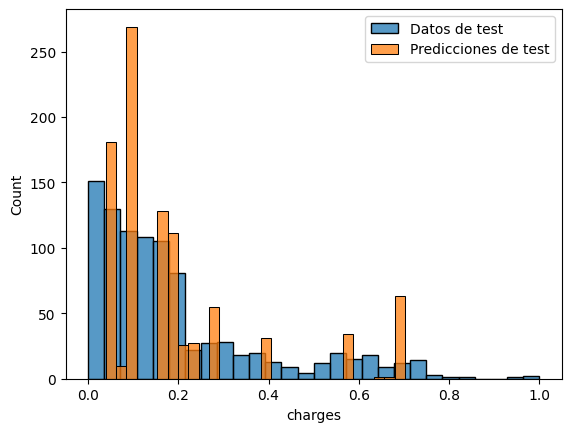

In [66]:
pred_train_6, pred_test_6, y_train_des, y_test_des = predecir_y_desescalar(modelo_6_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_6, y_test_des, pred_test_6, nombre_modelo="Adaptative Boosting")

## Gradient Boosting

Las métricas de desempeño en entrenamiento para Gradient Boosting son:
R2: 0.8493018320669815
RMSE: 0.07660894198168257
MAE: 0.027809475780852536
MAPE: 1989032446.7283719


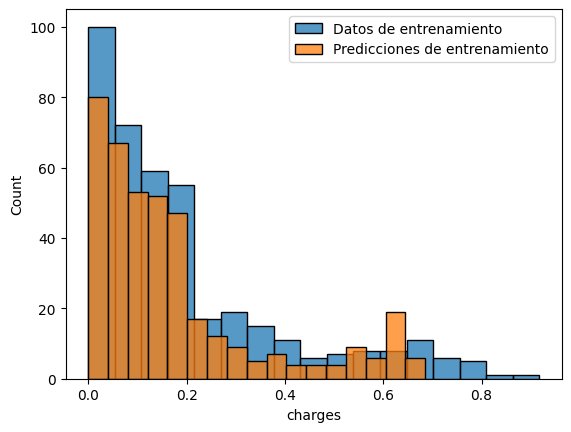

Las métricas de desempeño en test para Gradient Boosting son:
R2: 0.8178823937734901
RMSE: 0.08169278672758329
MAE: 0.03478789596497754
MAPE: 0.22293364591719184


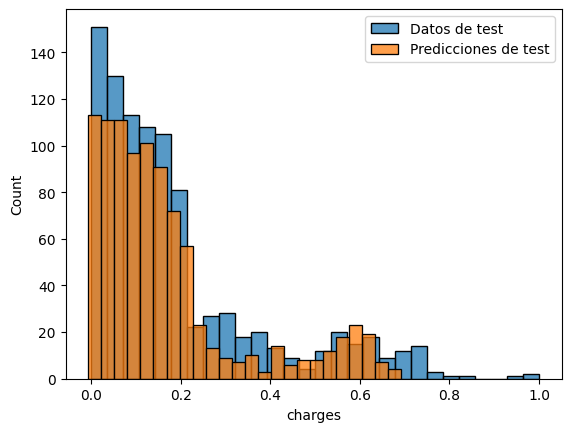

In [67]:
pred_train_7, pred_test_7, y_train_des, y_test_des = predecir_y_desescalar(modelo_7_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_7, y_test_des, pred_test_7, nombre_modelo="Gradient Boosting")

## Perceptor multicapa

Las métricas de desempeño en entrenamiento para Perceptor Multicapa son:
R2: 0.5487833932516437
RMSE: 0.13256168501191504
MAE: 0.09539034270747754
MAPE: 1112049513971.1929


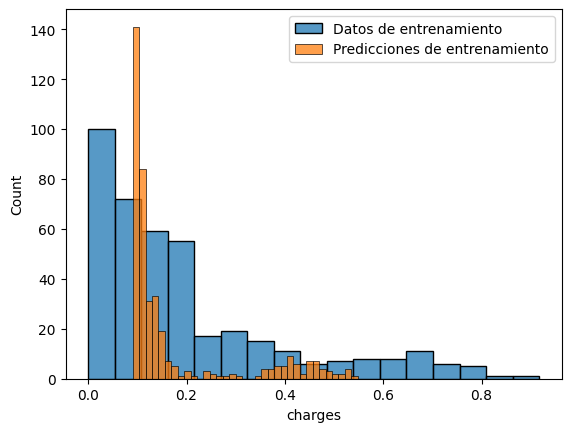

Las métricas de desempeño en test para Perceptor Multicapa son:
R2: 0.5198619273491605
RMSE: 0.13264497947304402
MAE: 0.09251038731172341
MAPE: 3.5773745433545274


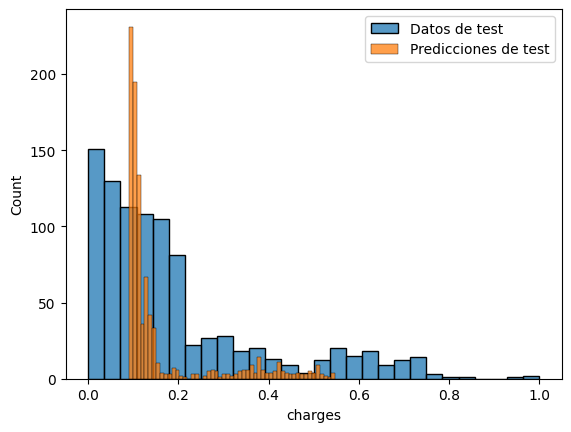

In [68]:
pred_train_8, pred_test_8, y_train_des, y_test_des = predecir_y_desescalar(modelo_8_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_8, y_test_des, pred_test_8, nombre_modelo="Perceptor Multicapa")